# **03 Diagnóstico estatístico visual**

---

#### Este arquivo é responsável pelo diágnóstico estatístico visual, buscando entender e responder perguntas de forma mais clara e obetiva por meio de gráficos

## Perguntas e valores análisadas


- **Análise de Idade**: Os funcionários demitidos possuem perfil etário diferente dos funcionários ativos ?

- **Análise Salarial**: Existe relação entre a remuneração mensal e o desligamento dos funcionários ?

- **Análise de Distância de Casa**: A distância entre a residência e o trabalho influencia no atrito e na retenção ?

- **Análise de Tempo de Empresa**: Os funcionários recém-contratados saem mais da empresa ou apresentam maior risco de desligamento ?

- **Análise de Horas Extras**: A realização de horas extras e a carga de trabalho estão associadas ao aumento do atrito ?

- **Análise de Satisfação dos Funcionários**: Funcionários menos satisfeitos com o ambiente, trabalho, gestor e equilíbrio de vida tendem a sair mais ?

- **Análise de Departamento**: Quais departamentos e áreas da empresa apresentam maior atrito e são mais afetados pelas demissões ?

- **Análise de Cargo**: Quais cargos e posições hierárquicas apresentam maior rotatividade e volume de desligamentos ?

- **Análise de Escolaridade**: O nível educacional dos colaboradores possui relação direta com a taxa de demissão ?

- **Matriz de Correlação**: Quais são as relações, correlações fortes e redundâncias entre as variáveis numéricas mapeadas ?

- **Ranking Final de Fatores de Atrito**: Quais fatores consolidados parecem ter maior influência e relevância para prever o desligamento ?


---

# Código:

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/tabela_base_traduzida.csv')

sns.set_theme( style = "darkgrid", palette = "cividis", context = "notebook")

### **Análise de Idade**
Os funcionários demitidos possuem perfil etário diferente dos funcionários ativos ?

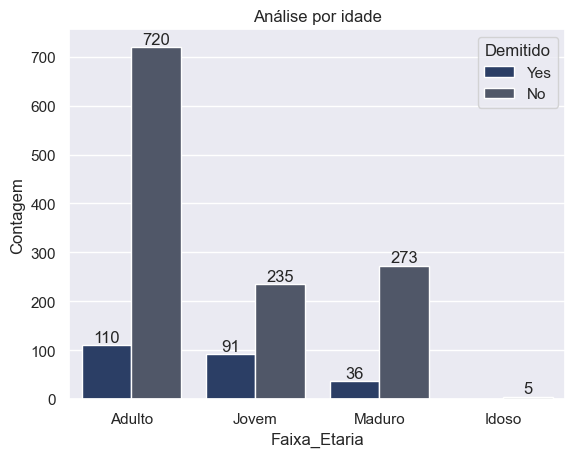

In [100]:
ordem = (df["Faixa_Etaria"].value_counts(ascending=False).index)

g = sns.countplot(data = df, x = "Faixa_Etaria", hue = "Demitido", order = ordem)
g.set_title("Análise por idade")
g.set_ylabel("Contagem")
g.label_outer("Teste")

for container in g.containers:
    g.bar_label(container, fmt = "%.0f")

#gi.text(x=1 (posição horizontal), y=50 (Posição vertical), s = "Texto") 

### **Análise Salarial**
Existe relação entre a remuneração mensal e o desligamento dos funcionários ?

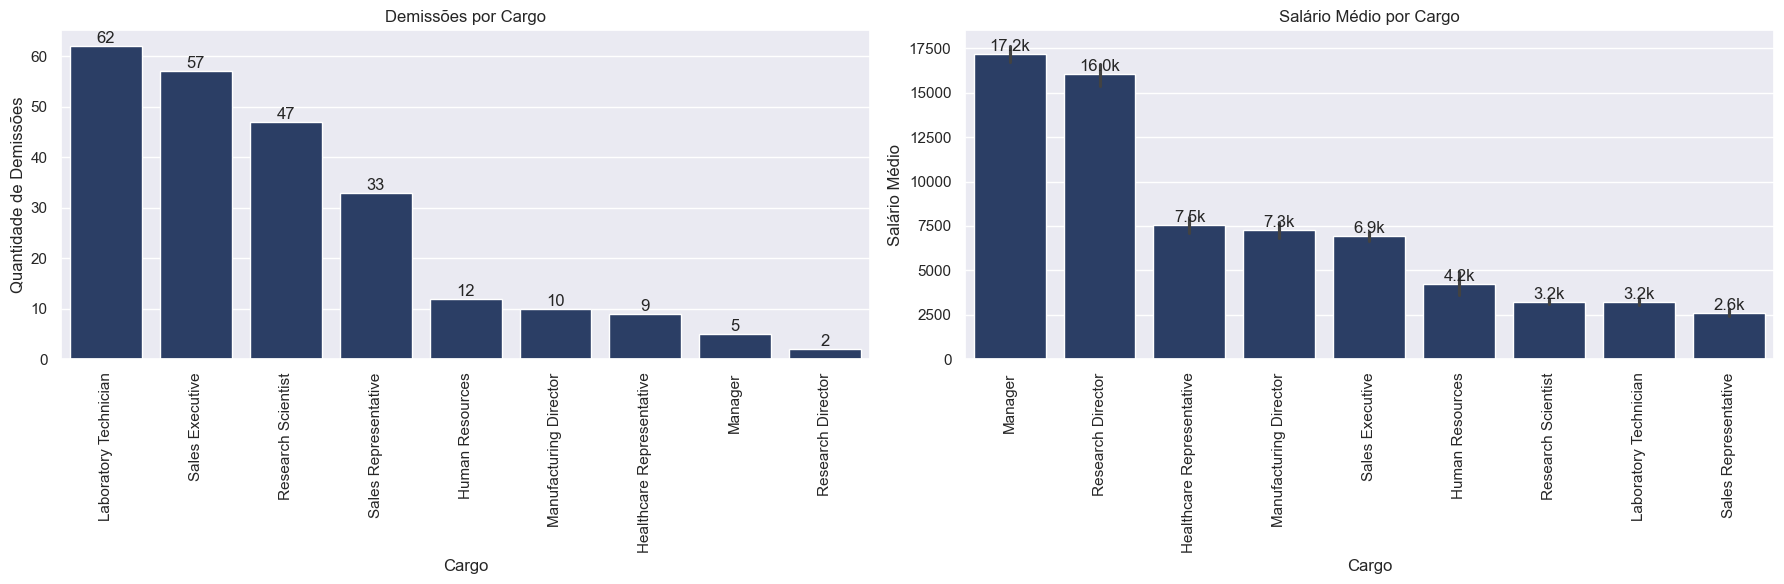

In [99]:
ordem_demissao_cargo = (df[df["Demitido"] == "Yes"]["Cargo"].value_counts(ascending=False).index)

ordem_salario_cargo = (df.groupby("Cargo")["Renda_Mensal"].mean().sort_values(ascending=False).index)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data = df[df["Demitido"] == "Yes"], x = "Cargo", order = ordem_demissao_cargo, ax = ax[0])
ax[0].set_title("Demissões por Cargo")
ax[0].set_xlabel("Cargo")
ax[0].set_ylabel("Quantidade de Demissões")


for container in ax[0].containers:
    ax[0].bar_label(container, fmt = "%.0f")

sns.barplot(data=df, x = "Cargo", y = "Renda_Mensal", estimator = "mean", order = ordem_salario_cargo, ax = ax[1])
ax[1].set_title("Salário Médio por Cargo")
ax[1].set_xlabel("Cargo")
ax[1].set_ylabel("Salário Médio")

for container in ax[1].containers:
    labels = [f"{v/1000:.1f}k" for v in container.datavalues]
    ax[1].bar_label(container, labels=labels)

for eixo in ax: eixo.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### **Análise de Distância de Casa:** 
    A distância entre a residência e o trabalho influencia no atrito e nas demissões ?

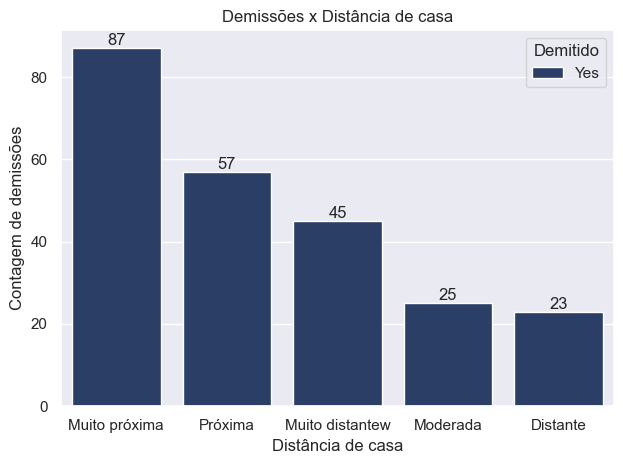

In [94]:
ordem_distancia = ( df[df["Demitido"] == "Yes"] ["Faixa_Distancia_de_Casa"].value_counts().index)

g = sns.countplot( data = df[df["Demitido"] == "Yes"], x = "Faixa_Distancia_de_Casa", hue = "Demitido", order = ordem_distancia)
g.set_xlabel("Distância de casa")
g.set_ylabel("Contagem de demissões")
g.set_title("Demissões x Distância de casa")

for container in g.containers:
    g.bar_label(container, fmt = "%.0f")

plt.tight_layout()
plt.show()

### **Análise de Tempo de Empresa**
    Os funcionários recém-contratados saem mais da empresa ou apresentam maior risco de desligamento ?

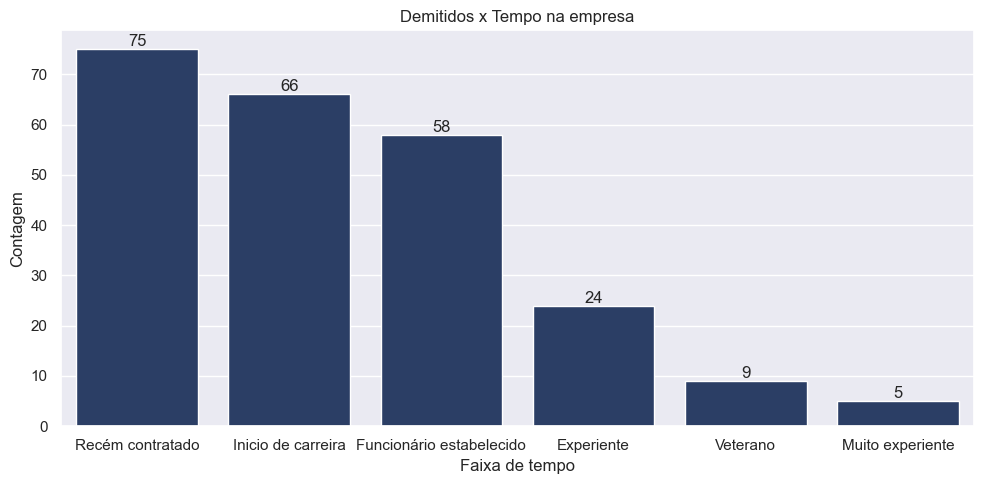

In [93]:
ordem = (df[df["Demitido"] == "Yes"]["Faixa_de_tempo_empresa"].value_counts().index)

plt.figure(figsize = (10,5))
g = sns.countplot(data = df[df["Demitido"] == "Yes"], x = "Faixa_de_tempo_empresa", order = ordem)
g.set_title("Demitidos x Tempo na empresa")
g.set_xlabel("Faixa de tempo")
g.set_ylabel("Contagem")

for container in g.containers:
    g.bar_label(container, fmt = "%.0f")

plt.tight_layout()
plt.show()

### **Análise de Horas Extras** 
A realização de horas extras e a carga de trabalho estão associadas ao aumento do atrito ?


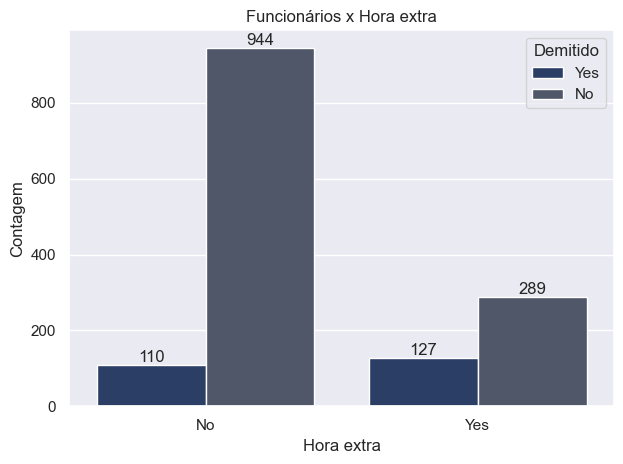

In [92]:
ordem = (df["Hora_Extra"].value_counts(ascending = False).index)
g = sns.countplot(data = df, x = "Hora_Extra", hue = "Demitido", order = ordem)
g.set_title("Funcionários x Hora extra")
g.set_xlabel("Hora extra")
g.set_ylabel("Contagem")

for container in g.containers:
    g.bar_label(container, fmt = "%.0f")

plt.tight_layout()
plt.show()

### **Análise de Satisfação dos Funcionários**
Funcionários menos satisfeitos com o ambiente, trabalho, gestor e equilíbrio de vida tendem a sair mais ?


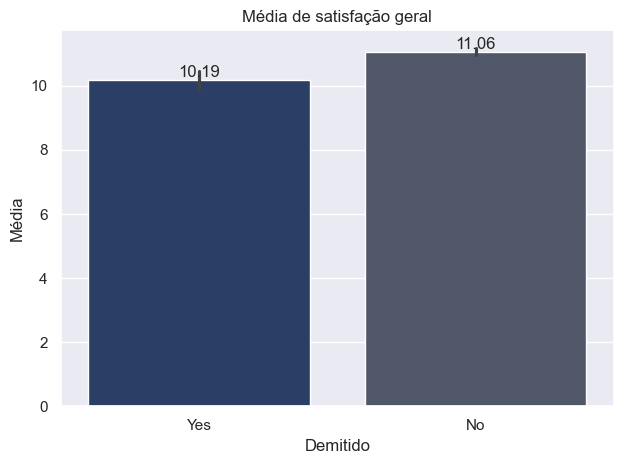

In [91]:
x = (df[df["Demitido"] == "Yes"]["Satisfação_geral"]).mean().round(2)
y = (df[df["Demitido"] == "No"]["Satisfação_geral"]).mean().round(2)

lista = [x, y]

g = sns.barplot( data = df, x = "Demitido", y = "Satisfação_geral", estimator = "mean", hue = "Demitido")
g.set_title("Média de satisfação geral")
g.set_ylabel("Média")

for container in g.containers:
    g.bar_label(container, fmt = "%.2f")

plt.tight_layout()
plt.show()

### **Análise de Departamento** 
Quais departamentos e áreas da empresa apresentam maior atrito e são mais afetados pelas demissões ?


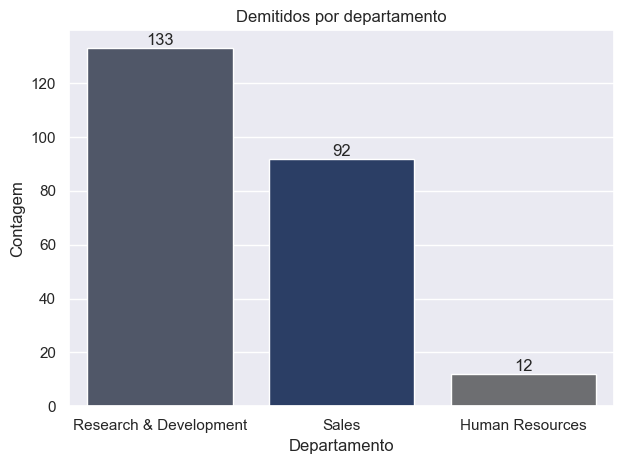

In [90]:
ordem = df[df["Demitido"] == "Yes"]["Departamento"].value_counts().index

g = sns.countplot(data = df[df["Demitido"] == "Yes"], x = "Departamento", hue = "Departamento", order = ordem)
g.set_title("Demitidos por departamento")
g.set_ylabel("Contagem")

for container in g.containers:
    g.bar_label(container, fmt = "%.0f")

plt.tight_layout()
plt.show()

### **Análise de Cargo**
Quais cargos e posições hierárquicas apresentam maior rotatividade e volume de desligamentos ?


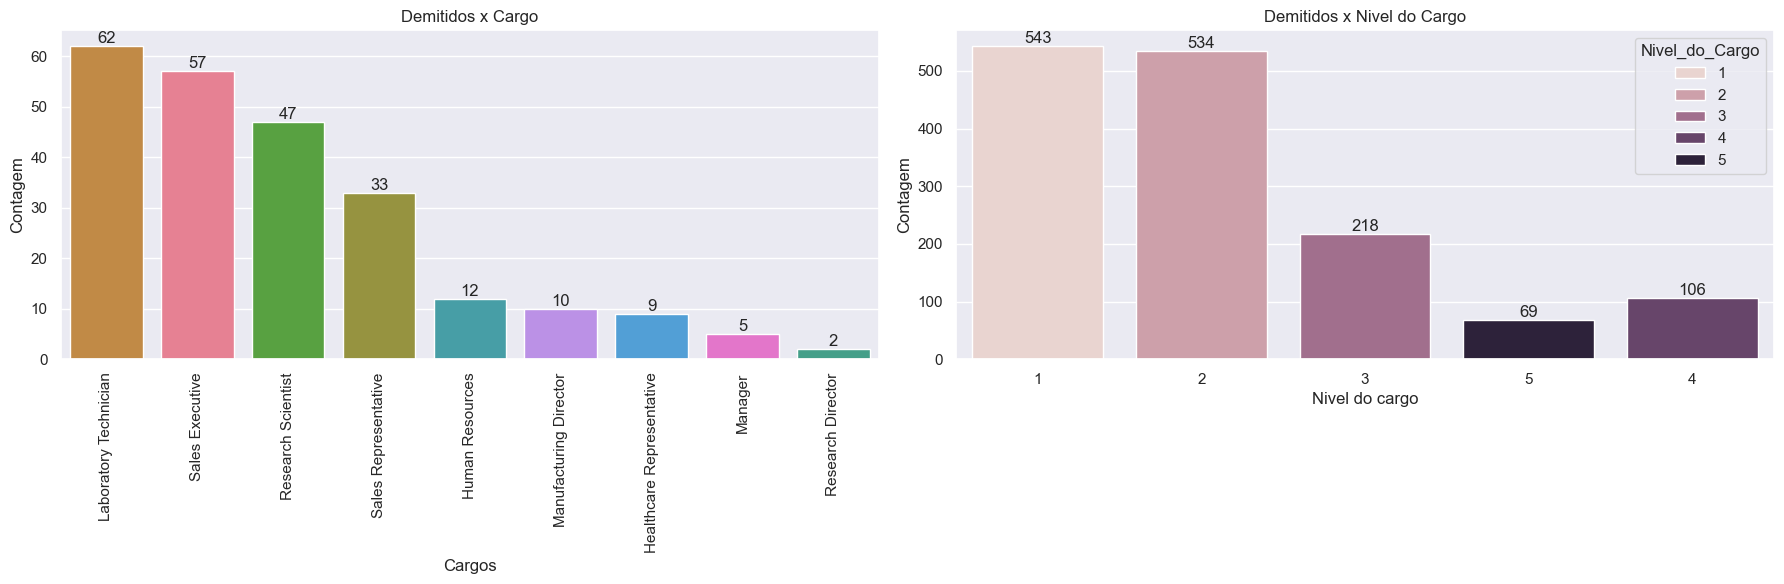

In [89]:
ordem_demissao_cargo = (df[df["Demitido"] == "Yes"]["Cargo"].value_counts(ascending=False).index)
ordem_demissao_nivel = (df[df["Demitido"] == "Yes"]["Nivel_do_Cargo"].value_counts(ascending = False).index)

fig, ax = plt.subplots(1, 2, figsize = (18, 6))

sns.countplot(data = df[df["Demitido"] == "Yes"], x = "Cargo", hue = "Cargo", order = ordem_demissao_cargo, ax = ax[0])
ax[0].set_title("Demitidos x Cargo")
ax[0].set_xlabel("Cargos")
ax[0].set_ylabel("Contagem")
ax[0].tick_params(axis = "x", rotation = 90)

for container in ax[0].containers:
    ax[0].bar_label(container, fmt = "%.0f")


sns.countplot(data = df, x = "Nivel_do_Cargo", hue = "Nivel_do_Cargo", order = ordem_demissao_nivel, ax = ax[1])
ax[1].set_title("Demitidos x Nivel do Cargo")
ax[1].set_xlabel("Nivel do cargo")
ax[1].set_ylabel("Contagem")

for container in ax[1].containers:
    ax[1].bar_label(container, fmt = "%.0f")



plt.tight_layout()
plt.show()


### **Análise de Escolaridade**
O nível educacional dos colaboradores possui relação direta com a taxa de demissão ?


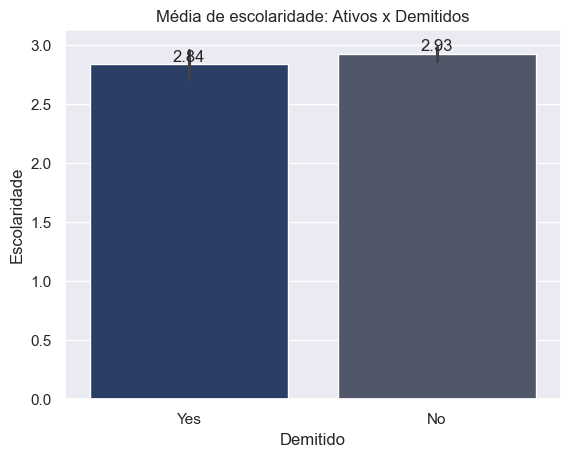

In [79]:
x = df.groupby("Demitido")["Escolaridade"].mean().round(2)

g = sns.barplot(data = df, x = "Demitido", y = "Escolaridade", estimator = "mean", hue = "Demitido")
g.set_title("Média de escolaridade: Ativos x Demitidos")
g.set_ylabel("Escolaridade")

for container in g.containers:
    g.bar_label(container, fmt = "%.2f")

### **Matriz de Correlação**
Quais são as relações, correlações fortes e redundâncias entre as variáveis numéricas mapeadas ?



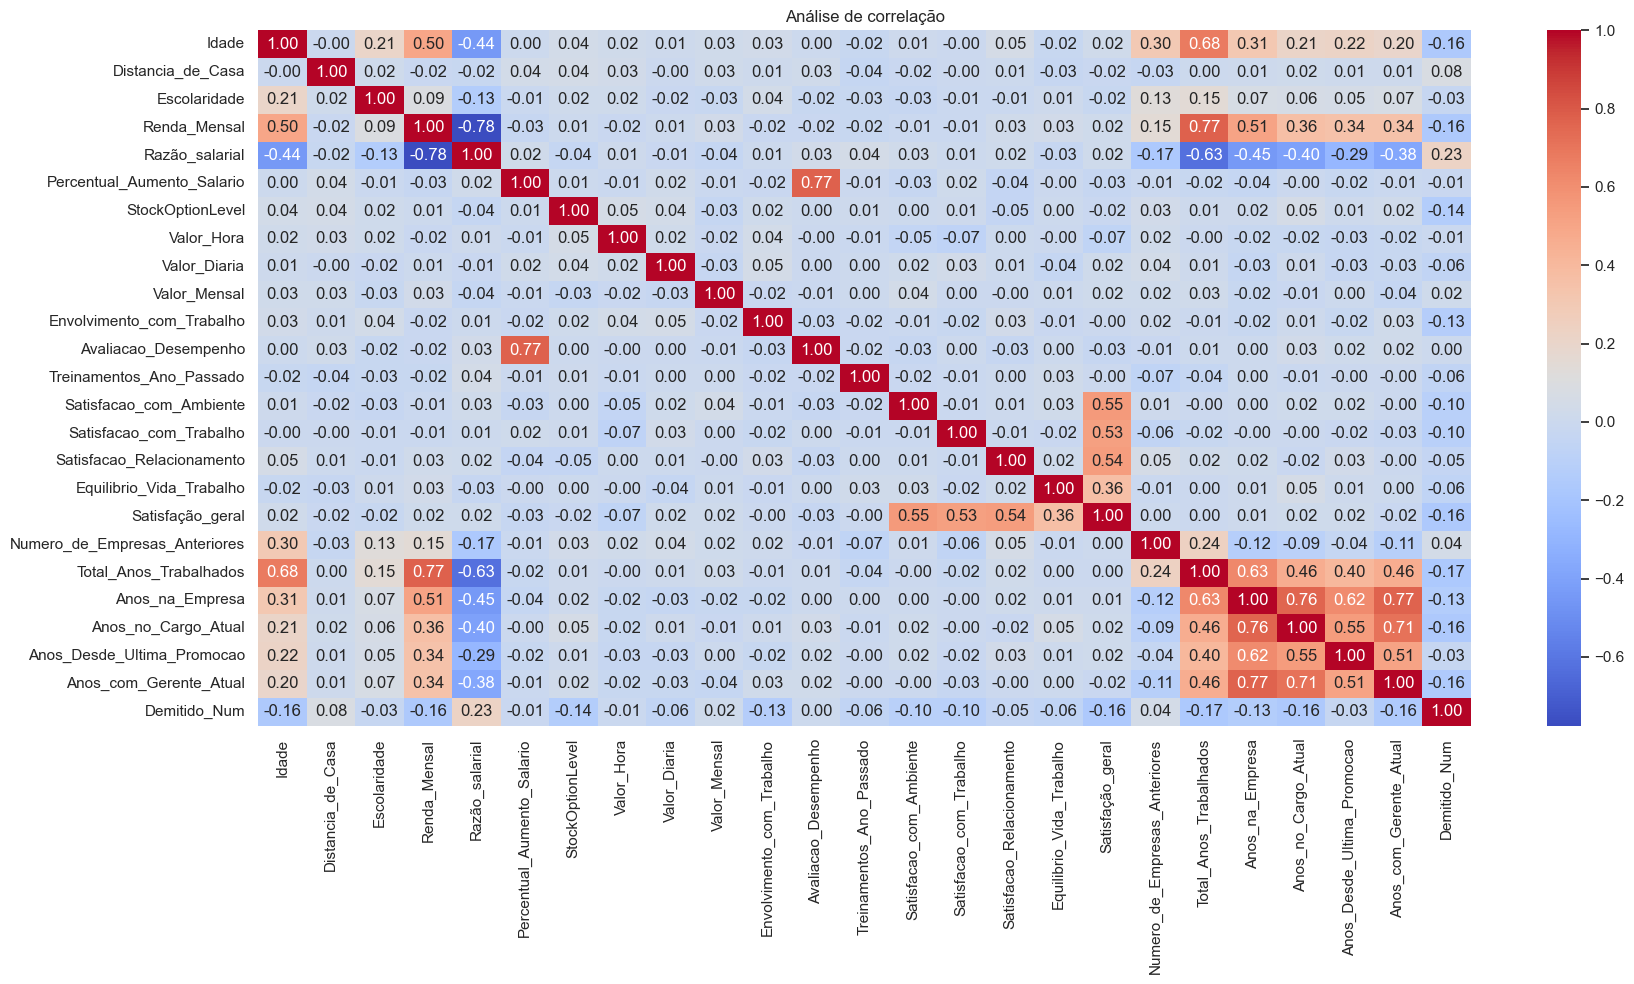

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [ ]:
df["Demitido_Num"] = df["Demitido"].map({ "No": 0, "Yes": 1})

colunas = [
    "Idade",
    "Distancia_de_Casa",
    "Escolaridade",
    "Renda_Mensal",
    "Razão_salarial",
    "Percentual_Aumento_Salario",
    "StockOptionLevel",
    "Valor_Hora",
    "Valor_Diaria",
    "Valor_Mensal",
    "Envolvimento_com_Trabalho",
    "Avaliacao_Desempenho",
    "Treinamentos_Ano_Passado",
    "Satisfacao_com_Ambiente",
    "Satisfacao_com_Trabalho",
    "Satisfacao_Relacionamento",
    "Equilibrio_Vida_Trabalho",
    "Satisfação_geral",
    "Numero_de_Empresas_Anteriores",
    "Total_Anos_Trabalhados",
    "Anos_na_Empresa",
    "Anos_no_Cargo_Atual",
    "Anos_Desde_Ultima_Promocao",
    "Anos_com_Gerente_Atual",
    "Demitido_Num"
]

corr = df[colunas].corr()





plt.figure(figsize = (18, 10))

g = sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
g.set_title("Análise de correlação")


plt.tight_layout()
plt.show()
